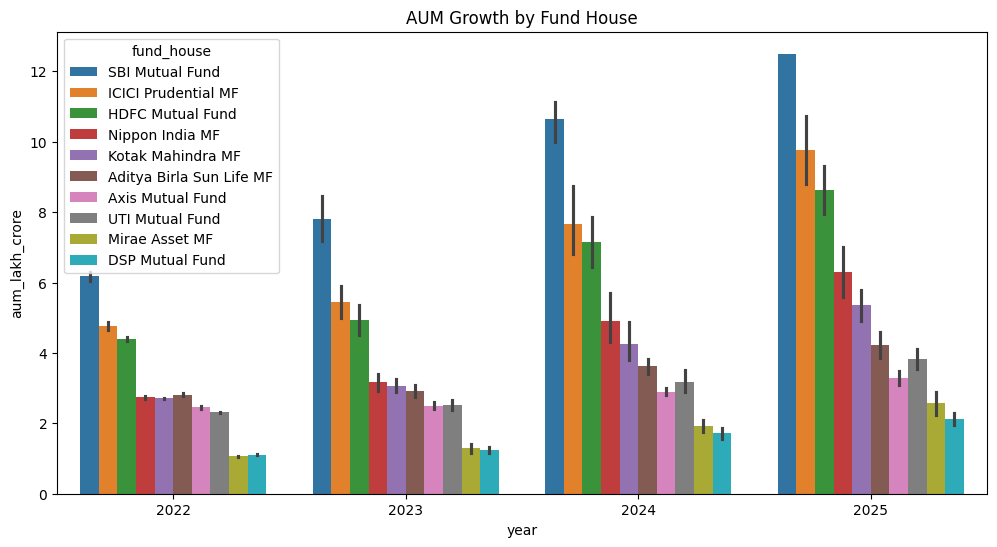

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(12,6))
sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)
plt.title("AUM Growth by Fund House")
plt.show()

In [13]:
import plotly.express as px

sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.show()

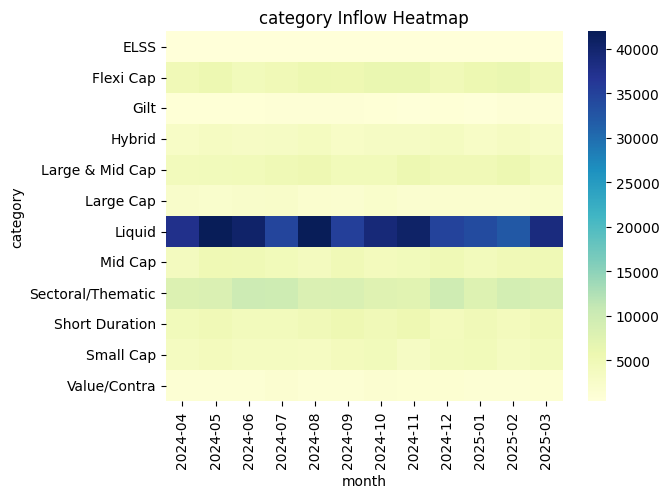

In [16]:
import pandas as pd

category = pd.read_csv(
    "../data/processed/clean_category_inflows.csv"
)

category.head()
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)
plt.title("category Inflow Heatmap")
plt.show()

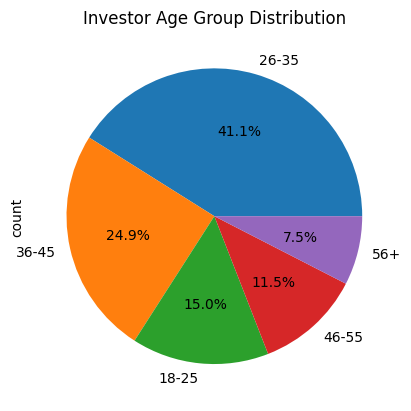

In [20]:
import pandas as pd

txn = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

txn.head()
txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Investor Age Group Distribution")
plt.show()

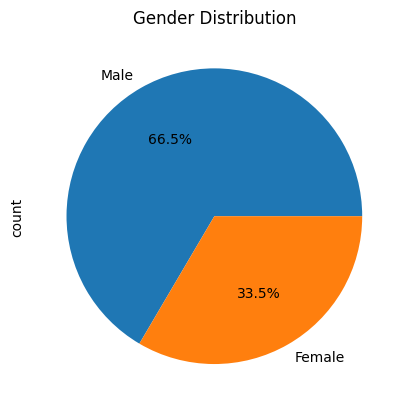

In [21]:

txn["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Gender Distribution")
plt.show()

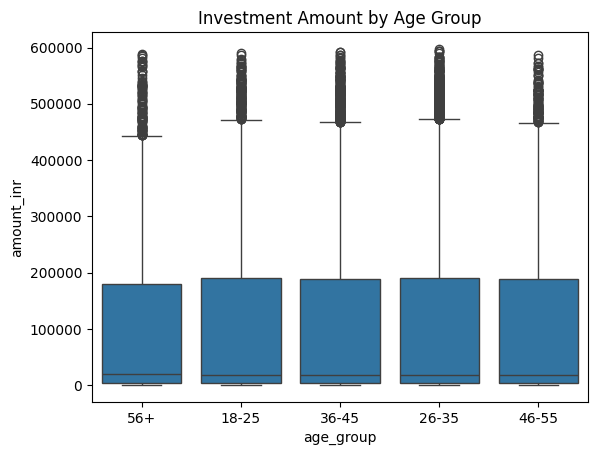

In [22]:
sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.show()

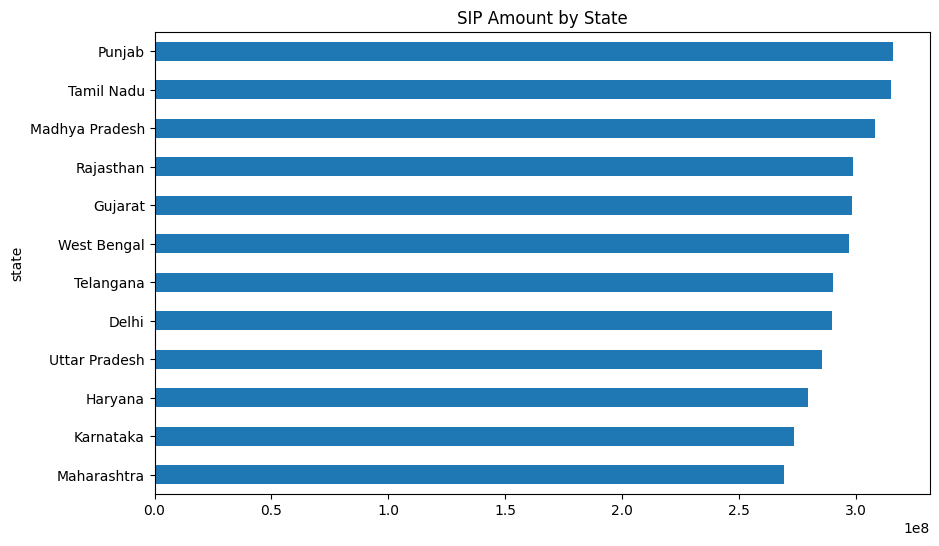

In [23]:
state_amount = txn.groupby(
    "state"
)["amount_inr"].sum()

state_amount.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("SIP Amount by State")
plt.show()

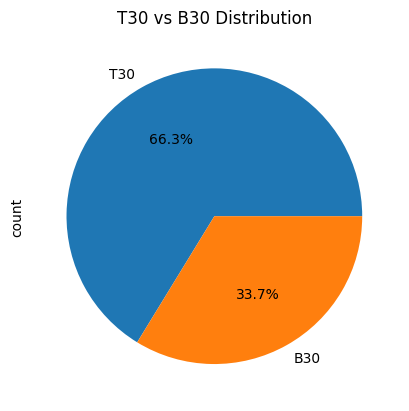

In [24]:
txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.show()

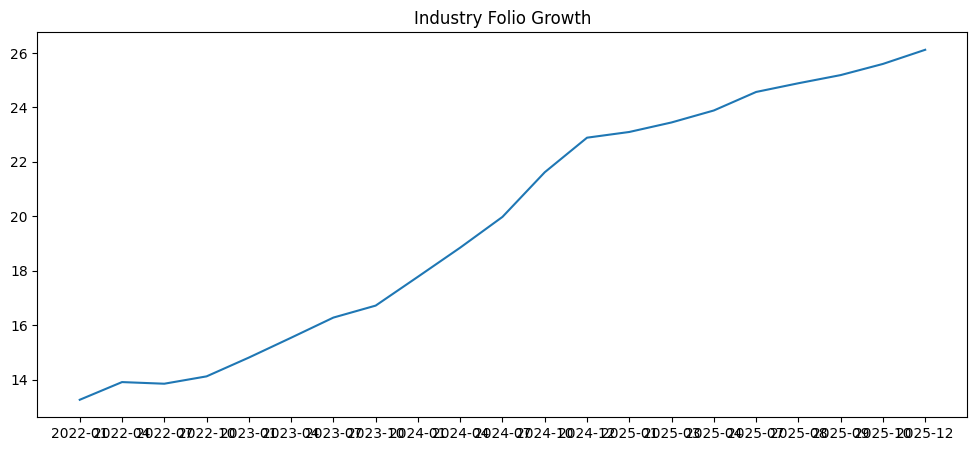

In [25]:
folio = pd.read_csv(
    "../data/processed/clean_industry_folio_count.csv"
)

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.show()

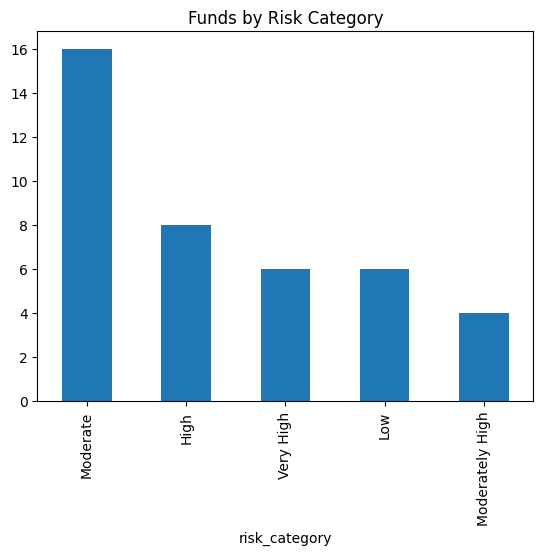

In [27]:
import pandas as pd
fund=pd.read_csv("../data/processed/clean_fund_master.csv")
fund.head()
fund["risk_category"].value_counts().plot(
    kind="bar"
)

plt.title("Funds by Risk Category")
plt.show()

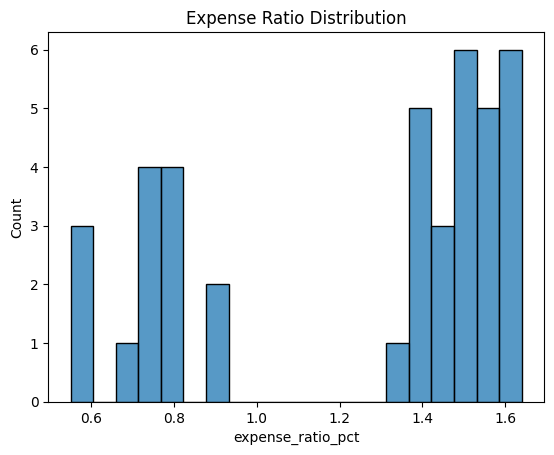

In [31]:
import pandas as pd
perf=pd.read_csv("../data/processed/clean_performance.csv")
perf.head()
sns.histplot(
    perf["expense_ratio_pct"],
    bins=20
)

plt.title("Expense Ratio Distribution")
plt.show()

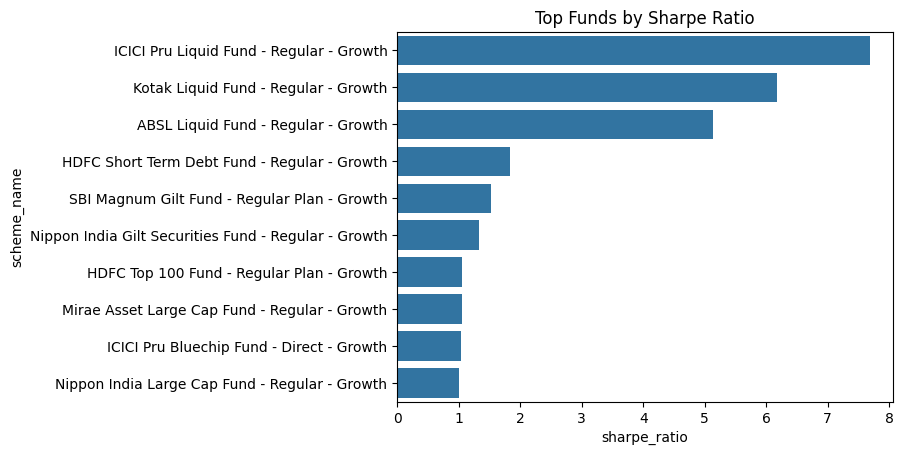

In [32]:
top_sharpe = perf.nlargest(
    10,
    "sharpe_ratio"
)

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top Funds by Sharpe Ratio")
plt.show()

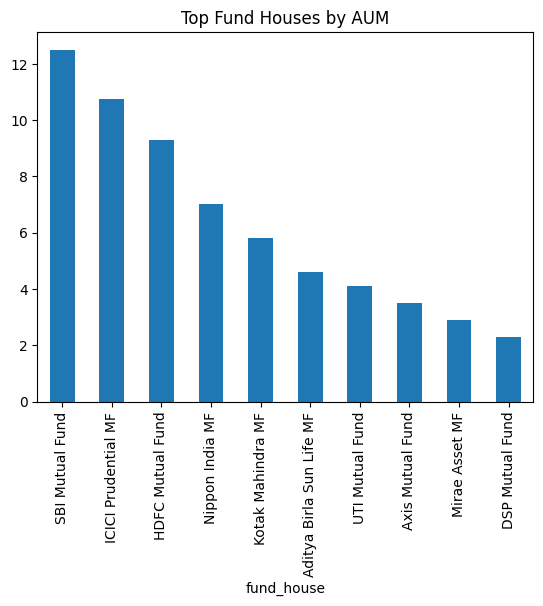

In [33]:
top_aum = aum.groupby(
    "fund_house"
)["aum_lakh_crore"].max()

top_aum.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title("Top Fund Houses by AUM")
plt.show()

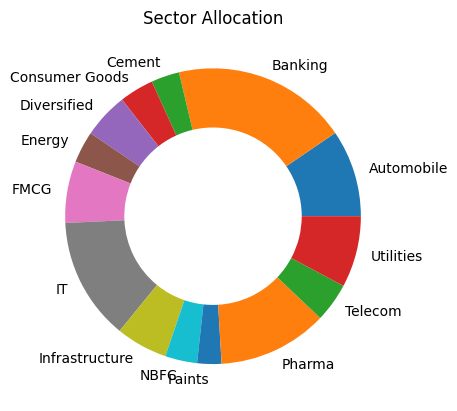

In [36]:
import pandas as pd
portfolio=pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
portfolio.head()
sector = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation")
plt.show()

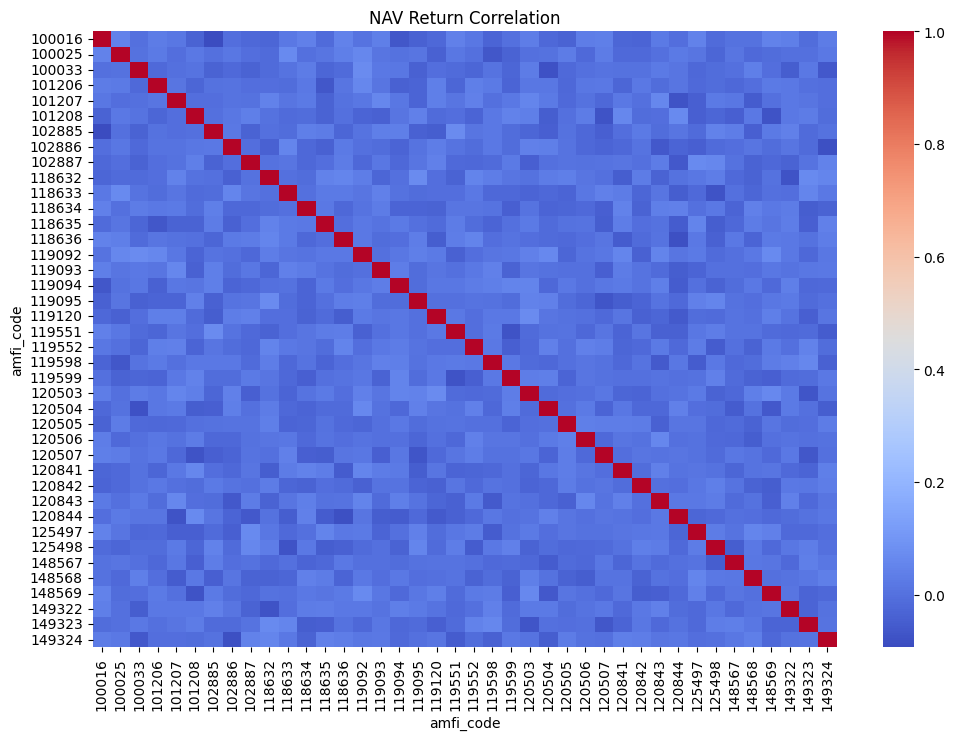

In [37]:
nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")
plt.show()